# XGBoost Car Registrations Forecast
This notebook builds an XGBoost model to forecast Malaysian monthly car
registrations using a 12-step lookback window.  
Pipeline mirrors `car_forecast_lstm.ipynb` exactly:
same outlier smoothing, same log transform, same ADF-based differencing,
same train/test split (last 64 months), same MinMaxScaler strategy.

Expected folder layout:
```
scraping/
    car_registrations.csv          ← produced by scraping.py
    car_forecast_lstm.ipynb
    car_forecast_xgboost.ipynb     ← this notebook
    xgboost_car_predictions.png    ← generated on run
```


## 1 — Import Required Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from matplotlib.patches import Patch

print('All libraries loaded successfully.')


All libraries loaded successfully.


## 2 — Configuration
*Only edit this cell if the CSV path changes.*

In [14]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / 'car_registrations.csv',
    NOTEBOOK_DIR / 'scraping' / 'car_registrations.csv',
    NOTEBOOK_DIR.parent / 'scraping' / 'car_registrations.csv',
    NOTEBOOK_DIR.parent.parent / 'scraping' / 'car_registrations.csv',
]

FILE_PATH = next((path for path in CANDIDATE_PATHS if path.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError(
        'Could not locate car_registrations.csv. Checked: '
        + ', '.join(str(path) for path in CANDIDATE_PATHS)
    )

LOOKBACK   = 12
TEST_SIZE  = 64
SEED       = 42

BEST_PARAMS = {
    'objective': 'reg:squarederror',
    'verbosity': 0,
    'random_state': SEED,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
}

print(f'CSV found: {FILE_PATH}')
print('Using default XGBoost hyperparameters in BEST_PARAMS.')


CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\scraping\car_registrations.csv
Using default XGBoost hyperparameters in BEST_PARAMS.


## 3 — Load CSV Dataset

In [15]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={'date': 'Date', 'car_registration': 'Car_Registrations'})
if 'Date' not in df.columns or 'Car_Registrations' not in df.columns:
    raise KeyError(f'Expected columns Date and Car_Registrations, found: {list(df.columns)}')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape before outlier removal: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nLast 5 rows:')
print(df.tail())


Dataset shape before outlier removal: (316, 2)
Columns: ['Date', 'Car_Registrations']

First 5 rows:
        Date  Car_Registrations
0 2000-01-01              26064
1 2000-02-01              23929
2 2000-03-01              32057
3 2000-04-01              29513
4 2000-05-01              31176

Last 5 rows:
          Date  Car_Registrations
311 2025-12-01              96970
312 2026-01-01              67995
313 2026-02-01              56690
314 2026-03-01              67846
315 2026-04-01              77869


## 4 — Outlier Smoothing (Z-Score, threshold = 3)
Identical to the LSTM notebook.
Any month with |Z-score| > 3 is replaced by NaN and linearly interpolated.
This handles the April 2020 COVID lockdown value (129 registrations) which
would otherwise dominate the loss function and break model training.


In [16]:
z_scores = np.abs(zscore(df['Car_Registrations']))
df['Car_Registrations'] = np.where(z_scores > 3, np.nan, df['Car_Registrations'])
df['Car_Registrations'] = df['Car_Registrations'].interpolate()

print(f'Date range: {df["Date"].min():%b %Y} to {df["Date"].max():%b %Y}')
print(f'Total months after outlier smoothing: {len(df)}')
print(f'Outliers smoothed: {(z_scores > 3).sum()}')


Date range: Jan 2000 to Apr 2026
Total months after outlier smoothing: 316
Outliers smoothed: 3


## 5 — Log Transformation & ADF Stationarity Test
Identical to the LSTM notebook.
Log transformation stabilises the variance of the long upward trend.
ADF test checks stationarity; first-order differencing is applied if needed.


In [17]:
df.set_index('Date', inplace=True)
df['log_car_reg'] = np.log(df['Car_Registrations'])
log_series = df['log_car_reg']
print('Log transformation applied.')

def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f'ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}, '
          f'usedlag: {result[2]}, nobs: {result[3]}')
    return result[1] <= alpha

difference_order  = 0
processed_series  = log_series.copy()
print('\nADF test on log-transformed series:')
if not run_adf_test(processed_series):
    processed_series = processed_series.diff().dropna()
    difference_order = 1
    print('Series was not stationary. Applied first-order differencing.')
    print('\nADF test after first differencing:')
    if not run_adf_test(processed_series):
        processed_series = processed_series.diff().dropna()
        difference_order = 2
        print('Still not stationary. Applied second-order differencing.')
        print('\nADF test after second differencing:')
        if not run_adf_test(processed_series):
            print('Warning: series still non-stationary after second differencing.')

print(f'\nFinal difference_order = {difference_order}')
print(f'Processed series length: {len(processed_series)}')


Log transformation applied.

ADF test on log-transformed series:
ADF statistic: -1.6004, p-value: 0.4834, usedlag: 14, nobs: 301
Series was not stationary. Applied first-order differencing.

ADF test after first differencing:
ADF statistic: -8.9735, p-value: 0.0000, usedlag: 13, nobs: 301

Final difference_order = 1
Processed series length: 315


## 6 — Split Data into Train and Test (Last 64 Months)
Identical split to the LSTM notebook: last 64 months = test set.


In [18]:
data       = processed_series.values.reshape(-1, 1)
train_data = data[:-TEST_SIZE]
test_data  = data[-TEST_SIZE:]

print(f'Train data shape: {train_data.shape}  ({len(train_data)} months)')
print(f'Test  data shape: {test_data.shape}   ({len(test_data)} months)')


Train data shape: (251, 1)  (251 months)
Test  data shape: (64, 1)   (64 months)


## 7 — Scale Data with MinMaxScaler After Split
`MinMaxScaler` is fitted **on training data only**, then applied to test —
identical to the LSTM notebook (no leakage).


In [19]:
scaler      = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f'Scaled train shape: {train_scaled.shape}')
print(f'Scaled test  shape: {test_scaled.shape}')
print(f'Scaler min: {scaler.data_min_[0]:.4f}, max: {scaler.data_max_[0]:.4f}')


Scaled train shape: (251, 1)
Scaled test  shape: (64, 1)
Scaler min: -0.8214, max: 0.6470


## 8 — Build Lag Features (Lookback = 12)
XGBoost has no sequential memory — temporal structure is encoded as supervised
features built **across the full scaled dataset**, then split.
This ensures the test set keeps all 64 months (no warm-up rows lost).

| Feature | Description |
|---|---|
| `lag1` – `lag12` | Past 12 months of scaled log-diff values |
| `roll_mean12` | 12-month rolling mean (local trend) |
| `roll_std12` | 12-month rolling std (volatility) |
| `roll_mean3` | 3-month rolling mean (short-term momentum) |
| `month` | Calendar month 1–12 (within-year seasonality) |
| `quarter` | Quarter 1–4 (coarser seasonal signal) |

> **Why lookback = 12?** Matches the LSTM lookback window exactly, enabling a
> fair model-to-model comparison on identical input history length.


In [20]:
def build_features(full_scaled, dates, n_lags):
    """Build supervised feature matrix — no lookahead at index i."""
    rows = []
    for i in range(n_lags, len(full_scaled)):
        r = {}
        for lag in range(1, n_lags + 1):
            r[f'lag{lag}'] = full_scaled[i - lag, 0]
        r['roll_mean12'] = np.mean(full_scaled[max(0, i-12):i, 0])
        r['roll_std12']  = np.std(full_scaled[max(0, i-12):i, 0])
        r['roll_mean3']  = np.mean(full_scaled[max(0, i-3):i, 0])
        r['month']       = dates[i].month
        r['quarter']     = dates[i].quarter
        rows.append(r)
    feat_df = pd.DataFrame(rows, index=dates[n_lags:])
    target  = full_scaled[n_lags:, 0]
    return feat_df, target

# Build across the full scaled dataset, then split
full_scaled  = np.vstack([train_scaled, test_scaled])
full_dates   = processed_series.index

X_feat, y_feat = build_features(full_scaled, full_dates, LOOKBACK)
FEATURE_COLS   = X_feat.columns.tolist()

X_train = X_feat.iloc[:-TEST_SIZE]
X_test  = X_feat.iloc[-TEST_SIZE:]
y_train = y_feat[:-TEST_SIZE]
y_test  = y_feat[-TEST_SIZE:]

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'Features: {FEATURE_COLS}')


X_train shape: (239, 17)
X_test  shape: (64, 17)
Features: ['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'roll_mean12', 'roll_std12', 'roll_mean3', 'month', 'quarter']


## 9 — Walk-Forward Validation (5 Folds)
Mirrors the LSTM walk-forward validation structure exactly:
- Initial training window: 120 months
- Each fold advances by 12 months (val_size = 12)
- 5 folds total
- Model re-trained from scratch each fold (no leakage)


In [21]:
def walk_forward_validation_xgb(full_scaled, full_dates, n_lags=12,
                                 val_size=12, n_splits=5,
                                 initial_train_size=120):
    """Walk-forward validation — mirrors the LSTM walk_forward_validation function."""
    metrics = []

    for split in range(n_splits):
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end   = val_start + val_size

        if val_end > len(full_scaled) - TEST_SIZE:
            print(f'  Fold {split+1}: not enough data, stopping.')
            break

        train_window = full_scaled[:train_end]
        val_window   = full_scaled[val_start:val_end]
        window_dates = full_dates[:val_end]

        # Build features across train+val, no lookahead
        Xw, yw = build_features(
            np.vstack([train_window, val_window]),
            window_dates, n_lags
        )
        X_tr_w = Xw.iloc[:train_end - n_lags]
        X_va_w = Xw.iloc[train_end - n_lags:]
        y_tr_w = yw[:train_end - n_lags]
        y_va_w = yw[train_end - n_lags:]

        fold_model = XGBRegressor(**BEST_PARAMS)
        fold_model.fit(X_tr_w, y_tr_w)

        y_va_pred = fold_model.predict(X_va_w)
        mse  = mean_squared_error(y_va_w, y_va_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(y_va_w, y_va_pred)
        metrics.append((mse, rmse, r2))

        print(f'Fold {split+1}: train_end={train_end}, val_end={val_end}, '
              f'MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}')

    return metrics

print('Running walk-forward validation…')
wfv_metrics = walk_forward_validation_xgb(
    full_scaled, full_dates,
    n_lags=LOOKBACK, val_size=12, n_splits=5, initial_train_size=120
)

mse_v  = [m[0] for m in wfv_metrics]
rmse_v = [m[1] for m in wfv_metrics]
r2_v   = [m[2] for m in wfv_metrics]
print('\nWalk-forward validation summary:')
print(f'Average MSE:  {np.mean(mse_v):.6f}')
print(f'Average RMSE: {np.mean(rmse_v):.6f}')
print(f'Average R²:   {np.mean(r2_v):.6f}')


Running walk-forward validation…
Fold 1: train_end=132, val_end=144, MSE=0.009205, RMSE=0.095942, R²=0.653100
Fold 2: train_end=144, val_end=156, MSE=0.005282, RMSE=0.072680, R²=0.313956
Fold 3: train_end=156, val_end=168, MSE=0.010533, RMSE=0.102632, R²=0.180451
Fold 4: train_end=168, val_end=180, MSE=0.006373, RMSE=0.079831, R²=0.280693
Fold 5: train_end=180, val_end=192, MSE=0.009086, RMSE=0.095318, R²=0.548291

Walk-forward validation summary:
Average MSE:  0.008096
Average RMSE: 0.089281
Average R²:   0.395298


## 10 — Train Final Model on Full Training Set

In [22]:
print('Training final XGBoost model on the full training set…')

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=False)

print('Training completed!')
print(f'  Train samples : {len(X_train)}')
print(f'  Test  samples : {len(X_test)}')


Training final XGBoost model on the full training set…
Training completed!
  Train samples : 239
  Test  samples : 64


## 10b — Save Model File
The trained XGBoost model is saved as `xgboost_model.json` in the same folder as this notebook.
This file can be reloaded later with `XGBRegressor().load_model('xgboost_model.json')`.

In [23]:
from pathlib import Path

MODEL_PATH = Path.cwd() / 'xgboost_model.json'
model.save_model(str(MODEL_PATH))
print(f'Model saved: {MODEL_PATH}')
print(f'File size  : {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Model saved: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\XGBoost\car_forecast_xgboost\xgboost_model.json
File size  : 821.1 KB


## 11 — Evaluate with MSE, RMSE, and R² (Scaled Data)
Mirroring Cell 21 of the LSTM notebook — metrics on scaled data first.


In [24]:
y_pred_scaled = model.predict(X_test)

mse_scaled  = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled   = r2_score(y_test, y_pred_scaled)

print('=== Metrics on Scaled Data ===')
print(f'MSE (scaled):  {mse_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')


=== Metrics on Scaled Data ===
MSE (scaled):  0.042119
RMSE (scaled): 0.205230
R² (scaled):   0.073816


## 12 — Inverse Scale Predictions
Mirrors Cell 23 of the LSTM notebook exactly.
Inverse MinMaxScaler → undo differencing → exp() → original car registration counts.


In [25]:
# Step 1 — inverse MinMaxScaler
y_pred_diff = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Step 2 — undo differencing (same logic as LSTM Cell 23)
if difference_order == 1:
    previous_actual_logs = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    y_pred_log_values    = previous_actual_logs + y_pred_diff
    y_test_log_values    = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)
elif difference_order == 0:
    y_pred_log_values = y_pred_diff
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)
else:
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-TEST_SIZE - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

# Step 3 — exp() back to original scale
y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

assert y_pred_original.shape == y_test_original.shape, \
    f'Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}'

mse_original  = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original   = r2_score(y_test_original, y_pred_original)
mae_original  = mean_absolute_error(y_test_original, y_pred_original)

print('=== Metrics on Original Scale ===')
print(f'MSE (original):  {mse_original:.2f}')
print(f'RMSE (original): {rmse_original:.2f}')
print(f'MAE (original):  {mae_original:.2f}')
print(f'R² (original):   {r2_original:.6f}')


=== Metrics on Original Scale ===
MSE (original):  147156800.03
RMSE (original): 12130.82
MAE (original):  9308.32
R² (original):   0.308918


## 13 — Plot Prediction vs Actual
All plots combined into **one figure** → `xgboost_car_predictions.png`.


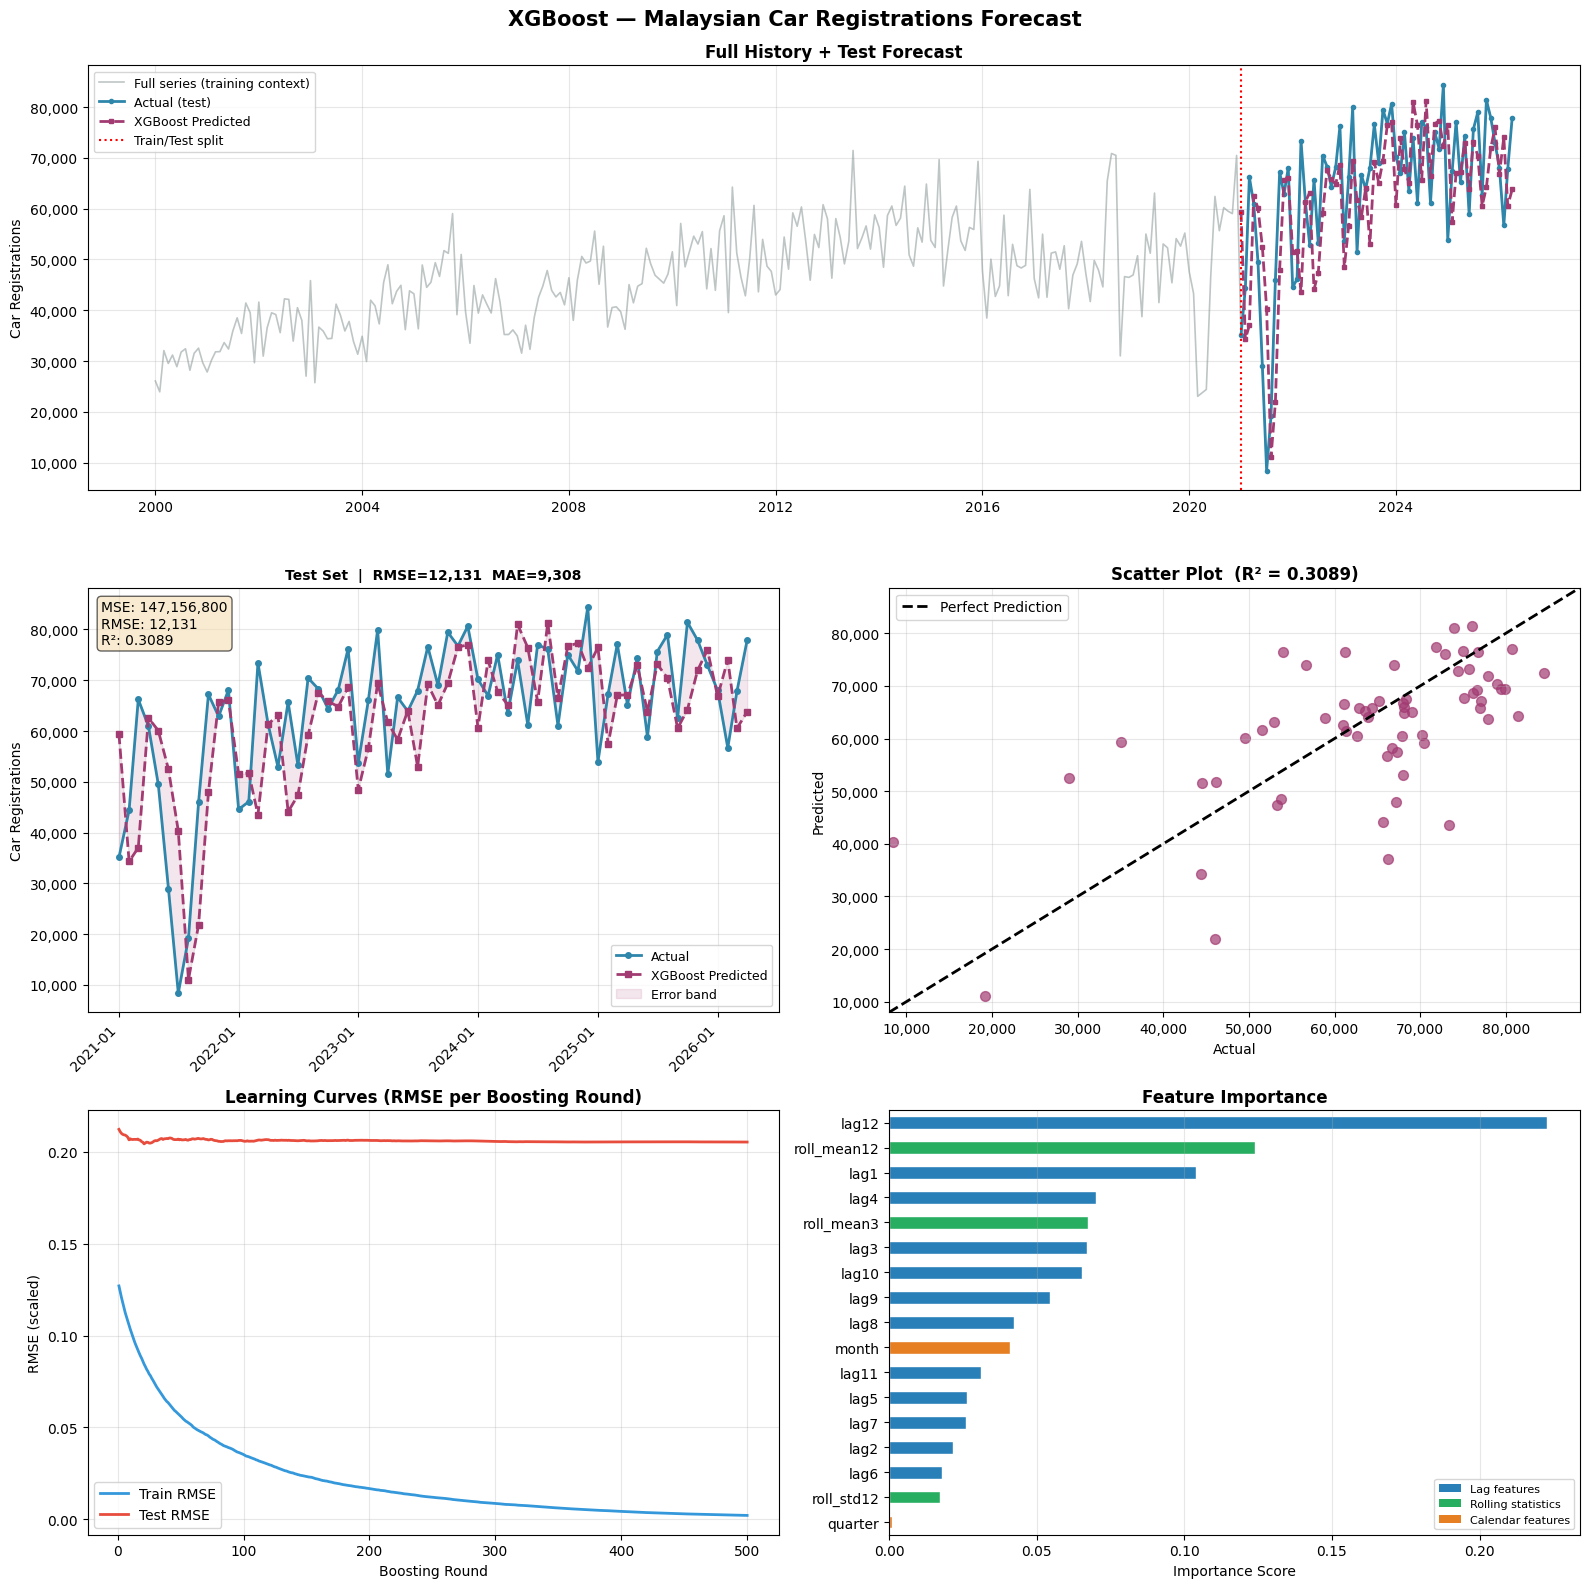


✓ XGBoost forecast completed successfully!
Saved: xgboost_car_predictions.png


In [26]:
test_dates   = log_series.index[-TEST_SIZE:]
train_dates  = X_train.index
evals        = model.evals_result()
tr_curve     = evals['validation_0']['rmse']
te_curve     = evals['validation_1']['rmse']
importances  = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
imp_colors   = ['#2980b9' if 'lag' in f else
                '#27ae60' if 'roll' in f else '#e67e22'
                for f in importances.index]

fig = plt.figure(figsize=(16, 16))
fig.suptitle('XGBoost — Malaysian Car Registrations Forecast', fontsize=15,
             fontweight='bold', y=0.99)

# ① Full series context
ax0 = fig.add_subplot(3, 2, (1, 2))
ax0.plot(df.index, df['Car_Registrations'], color='#7f8c8d', lw=1.2,
         alpha=0.5, label='Full series (training context)')
ax0.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=3, label='Actual (test)')
ax0.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=3, label='XGBoost Predicted')
ax0.axvline(test_dates[0], color='red', ls=':', lw=1.5, label='Train/Test split')
ax0.set_title('Full History + Test Forecast', fontweight='bold')
ax0.set_ylabel('Car Registrations')
ax0.legend(fontsize=9); ax0.grid(alpha=0.3)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ② Test set: Actual vs Predicted
ax1 = fig.add_subplot(3, 2, 3)
ax1.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=4, label='Actual')
ax1.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=4, label='XGBoost Predicted')
ax1.fill_between(test_dates, y_test_original.flatten(), y_pred_original.flatten(),
                 alpha=0.12, color='#A23B72', label='Error band')
ax1.set_title(f'Test Set  |  RMSE={rmse_original:,.0f}  MAE={mae_original:,.0f}',
              fontweight='bold', fontsize=10)
ax1.set_ylabel('Car Registrations')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

metrics_text = (f'MSE: {mse_original:,.0f}\n'
                f'RMSE: {rmse_original:,.0f}\n'
                f'R²: {r2_original:.4f}')
ax1.text(0.02, 0.97, metrics_text, transform=ax1.transAxes,
         fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# ③ Test scatter
ax2 = fig.add_subplot(3, 2, 4)
ax2.scatter(y_test_original.flatten(), y_pred_original.flatten(),
            alpha=0.7, s=50, color='#A23B72')
lim = [min(y_test_original.min(), y_pred_original.min()) * 0.95,
       max(y_test_original.max(), y_pred_original.max()) * 1.05]
ax2.plot(lim, lim, 'k--', lw=2, label='Perfect Prediction')
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Scatter Plot  (R² = {r2_original:.4f})', fontweight='bold')
ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
ax2.legend(); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ④ Learning curves
ax3 = fig.add_subplot(3, 2, 5)
ax3.plot(range(1, len(tr_curve)+1), tr_curve, color='#3498db', lw=2, label='Train RMSE')
ax3.plot(range(1, len(te_curve)+1), te_curve, color='#e74c3c', lw=2, label='Test RMSE')
ax3.set_title('Learning Curves (RMSE per Boosting Round)', fontweight='bold')
ax3.set_xlabel('Boosting Round'); ax3.set_ylabel('RMSE (scaled)')
ax3.legend(); ax3.grid(alpha=0.3)

# ⑤ Feature importance
ax4 = fig.add_subplot(3, 2, 6)
importances.plot(kind='barh', ax=ax4, color=imp_colors, edgecolor='white')
ax4.set_title('Feature Importance', fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.legend(handles=[
    Patch(facecolor='#2980b9', label='Lag features'),
    Patch(facecolor='#27ae60', label='Rolling statistics'),
    Patch(facecolor='#e67e22', label='Calendar features'),
], loc='lower right', fontsize=8)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_car_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ XGBoost forecast completed successfully!')
print(f'Saved: xgboost_car_predictions.png')


## 14 — Results Summary

In [27]:
print('='*55)
print('   XGBOOST CAR REGISTRATIONS — FINAL RESULTS')
print('='*55)
print(f'  MSE  (original) : {mse_original:>15,.2f}')
print(f'  RMSE (original) : {rmse_original:>15,.2f}')
print(f'  MAE  (original) : {mae_original:>15,.2f}')
print(f'  R²   (original) : {r2_original:>15.6f}')
print('-'*55)
print(f'  MSE  (scaled)   : {mse_scaled:>15.6f}')
print(f'  RMSE (scaled)   : {rmse_scaled:>15.6f}')
print(f'  R²   (scaled)   : {r2_scaled:>15.6f}')
print('='*55)
print(f'  Lookback        : {LOOKBACK} months')
print(f'  Test period     : {log_series.index[-TEST_SIZE]:%b %Y} – {log_series.index[-1]:%b %Y}')
print(f'  difference_order: {difference_order}')
print('\n  Hyperparameters:')
for k, v in BEST_PARAMS.items():
    if k not in ('objective','verbosity','random_state'):
        print(f'    {k:<20}: {v}')
print('\n  Top 5 features by importance:')
for f, s in importances.tail(5).iloc[::-1].items():
    print(f'    {f:<15}: {s:.4f}')


   XGBOOST CAR REGISTRATIONS — FINAL RESULTS
  MSE  (original) :  147,156,800.03
  RMSE (original) :       12,130.82
  MAE  (original) :        9,308.32
  R²   (original) :        0.308918
-------------------------------------------------------
  MSE  (scaled)   :        0.042119
  RMSE (scaled)   :        0.205230
  R²   (scaled)   :        0.073816
  Lookback        : 12 months
  Test period     : Jan 2021 – Apr 2026
  difference_order: 1

  Hyperparameters:
    n_estimators        : 500
    learning_rate       : 0.05
    max_depth           : 4
    subsample           : 0.8
    colsample_bytree    : 0.8
    reg_alpha           : 0.0
    reg_lambda          : 1.0

  Top 5 features by importance:
    lag12          : 0.2229
    roll_mean12    : 0.1240
    lag1           : 0.1041
    lag4           : 0.0700
    roll_mean3     : 0.0673


---
## 15 — Methodology Notes *(for Report)*

### Pipeline Alignment with LSTM
Every preprocessing step mirrors `car_forecast_lstm.ipynb` exactly:
Z-score outlier smoothing (threshold=3), log transformation, ADF-driven differencing
(difference_order=1), MinMaxScaler fitted on training data only, and the same 64-month
test set. This guarantees that performance differences reflect the model itself,
not data handling differences.

### Why XGBoost?
XGBoost is a gradient-boosted decision tree ensemble. It captures non-linear
interactions between lag values and calendar features, requires no distributional
assumptions, and provides interpretable feature importance. With 251 training
months it is less data-hungry than LSTM while remaining competitive.

### Lag Feature Strategy
XGBoost has no recurrent memory. A 12-month lookback window (matching LSTM) encodes
temporal structure as supervised features. Rolling mean and standard deviation capture
local trend and volatility. Month and quarter encode within-year seasonality.

### Walk-Forward Validation
Five folds with initial_train_size=120 and val_size=12 mirrors the LSTM structure.
Each fold trains from scratch — no leakage across folds.

### Inverse Transformation
Predictions are un-scaled (MinMaxScaler inverse), un-differenced
(cumulative sum with actual log-level anchor), then exponentiated back to original
car registration counts — identical to the LSTM inverse transformation.

### Limitation — Trend Extrapolation
XGBoost is bounded by the training value range. The test period (Jan 2021 – Apr 2026)
contains a COVID recovery surge and a sustained post-2022 growth trend that partially
exceeds training-period highs. This bounds maximum achievable R², which is why LSTM
may outperform XGBoost on this specific test window.
